# Customer Personality Analysis - Exploratory Data Analysis (EDA)

**Objective:** Analyze customer data to understand purchasing behavior, demographics, and campaign responses — ultimately to prepare the data for customer segmentation using clustering.

**Dataset:** `marketing_campaign.xlsx` — 2240 customers with 29 features covering:
- **People:** Demographics (age, education, marital status, income, children)
- **Products:** Amount spent on wines, fruits, meat, fish, sweets, gold
- **Promotion:** Campaign acceptance and deal purchases
- **Place:** Purchase channels (web, catalog, store) and website visits

---

## Step 1: Import Libraries

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Step 2: Load the Dataset

In [125]:
df = pd.read_excel('marketing_campaign.xlsx')
print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset Shape: 2240 rows x 29 columns


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


## Step 3: Understand the Data Structure

Let's check data types, non-null counts, and memory usage.

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   str           
 3   Marital_Status       2240 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[us]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-null   int64  

In [127]:
# Column names grouped by category for reference
people_cols = ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency']
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
promo_cols = ['NumDealsPurchases', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
place_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

print(f'People columns   ({len(people_cols)}): {people_cols}')
print(f'Product columns  ({len(product_cols)}): {product_cols}')
print(f'Promotion columns({len(promo_cols)}): {promo_cols}')
print(f'Place columns    ({len(place_cols)}): {place_cols}')
print(f'Other columns: ID, Complain, Z_CostContact, Z_Revenue')

People columns   (8): ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency']
Product columns  (6): ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
Promotion columns(7): ['NumDealsPurchases', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
Place columns    (4): ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
Other columns: ID, Complain, Z_CostContact, Z_Revenue


## Step 4: Check for Missing Values

In [128]:
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0]

missing_pct = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing_Count": missing_count.values,
    "Missing_Percentage": missing_pct.values
})

if not missing_df.empty:
    print(missing_df)
else:
    print("No missing values found!")

   Missing_Count  Missing_Percentage
0             24                1.07


In [129]:
# Fill missing Income values with the median
print(f'count of missing Income values: {df["Income"].isnull().sum()} out of {len(df)}')
df['Income'] = df['Income'].fillna(df['Income'].median())
print(f'After filling: {df["Income"].isnull().sum()} missing values')

count of missing Income values: 24 out of 2240
After filling: 0 missing values


## Step 5: Check for Duplicate Rows

In [130]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

# Also check if IDs are unique
print(f'Unique IDs: {df["ID"].nunique()} out of {len(df)} rows')

Number of duplicate rows: 0
Unique IDs: 2240 out of 2240 rows


## Step 6: Feature Engineering


### 6a. Feature Categorization

Creating useful derived features before deep-diving into analysis.

The following features were engineered to capture customer demographics, spending behavior, purchasing activity, family structure, marketing responsiveness, and loyalty duration.

# Why These 6 Features for Feature Engineering?

Not every column in the dataset directly represents meaningful customer behavior.
The following six engineered features — `Total_Spend `, `Total_Purchases`,`Total_Campaigns_Accepted`, `Total_Dependents`, `Customer_Tenure_Days`, and `Is_Parent` — were created to transform raw transactional data into behavior-focused indicators that better capture customer value, engagement, household structure, and loyalty.

---

**1. `Total_Spend` — Overall Customer Value**

Customers purchase multiple product categories.
- Wines
- Fruits
- Meat Product
- Fish Product
- Sweet Products
- Gold Products

Instead of analyzing each product category separately, these values are combined into a single feature to represent the total amount spent by a customer across all products.


**2. `Total_Purchases` — Overall Purchase Activitys**

Customers interact with the company through three main purchasing channels:
- Web purchases
- Catalog purchases
- Store purchases

Instead of analyzing them separately, they are combined to represent total purchasing frequency.

`Note:`We excluded NumDealsPurchases as it counts purchases made with discounts, not a separate sales channel.

**3. `Total_Campaigns_Accepted` — Marketing Responsiveness**

Customers were exposed to five marketing campaigns.

The dataset includes separate columns for each campaign:
- AcceptedCmp1
- AcceptedCmp2
- AcceptedCmp3
- AcceptedCmp4
- AcceptedCmp5

These are aggregated to measure overall marketing responsiveness.

**4. `Total_Dependents` — Household Size Indicator**

The dataset includes two columns representing children living at home:
- Kidhome
- Teenhome

These are combined to create a single household dependency variable.

Household size can strongly influence purchasing behavior, especially in food-related product categories.

**5. `Customer_Tenure_Days` — Loyalty Duration**

Customer tenure represents how long a customer has been associated with the company.

It is calculated using the difference between today's date and the enrollment date.

*Customer_Tenure_Days = Today - Dt_Customer*

Longer tenure often indicates:
- stronger brand loyalty
- higher lifetime value
- greater familiarity with the company

Short tenure may represent newly acquired customers who are still forming purchasing habits.

**6. `Is_Parent` — Binary Family Indicator**

A simplified feature is created to determine whether a customer has dependents or not.

*Is_Parent = 1 if Total_Dependents > 0*

*Is_Parent = 0 otherwise*

Instead of analyzing multiple family variables, we now have a clear indicator of parental status.

---

> **Takeaway:** Feature engineering transforms raw dataset columns into **behavioral indicators**. These engineered variables capture *customer value* (`Total_Spend`), *purchase engagement* (`Total_Purchases`), *marketing responsiveness* (`Total_Campaigns_Accepted`), *household structure* (`Total_Dependents`, `Is_Parent`), and *customer loyalty duration* (`Customer_Tenure_Days`). Together, they create a more meaningful representation of customers, which significantly improves **behavior analysis and segmentation models such as clustering**.

###6b. Feature Engineering Code

In [131]:
# Calculate customer's age using the current year
from datetime import datetime
df['Age'] = datetime.now().year - df['Year_Birth']

# Total spending across all product categories
df['Total_Spend'] = df[['MntWines', 'MntFruits', 'MntMeatProducts',
                         'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

# Total number of purchases across channels (Web + Catalog + Store only)
# Note: NumDealsPurchases counts discount-based purchases, not a separate channel
df['Total_Purchases'] = df[['NumWebPurchases', 'NumCatalogPurchases',
                            'NumStorePurchases']].sum(axis=1)

# Total dependents (kids + teens)
df['Total_Dependents'] = df['Kidhome'] + df['Teenhome']

# Binary flag: Is the customer a parent?
df['Is_Parent'] = (df['Total_Dependents'] > 0).astype(int)

# Total campaigns accepted (Campaigns 1-5 only, Response kept separate)
df['Total_Campaigns_Accepted'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                                     'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)

# Customer tenure in days (from enrollment date to today)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df['Customer_Tenure_Days'] = (pd.to_datetime('today') - df['Dt_Customer']).dt.days

print('New features created:')
print(df[['Age', 'Total_Spend', 'Total_Purchases', 'Total_Dependents',
          'Is_Parent', 'Total_Campaigns_Accepted', 'Customer_Tenure_Days']].describe().round(2))

New features created:
           Age  Total_Spend  Total_Purchases  Total_Dependents  Is_Parent  \
count  2240.00      2240.00          2240.00           2240.00    2240.00   
mean     57.19       605.80            12.54              0.95       0.72   
std      11.98       602.25             7.21              0.75       0.45   
min      30.00         5.00             0.00              0.00       0.00   
25%      49.00        68.75             6.00              0.00       0.00   
50%      56.00       396.00            12.00              1.00       1.00   
75%      67.00      1045.50            18.00              1.00       1.00   
max     133.00      2525.00            32.00              3.00       1.00   

       Total_Campaigns_Accepted  Customer_Tenure_Days  
count                   2240.00               2240.00  
mean                       0.30               4631.58  
std                        0.68                202.12  
min                        0.00               4278.00  
25% 

## Step 7: Descriptive Statistics

### 7a. Numerical Features

In [132]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
ID,2240.0,5592.159821,0.0,2828.25,5458.5,8427.75,11191.0,3246.662198
Year_Birth,2240.0,1968.805804,1893.0,1959.0,1970.0,1977.0,1996.0,11.984069
Income,2240.0,52237.975446,1730.0,35538.75,51381.5,68289.75,666666.0,25037.955891
Kidhome,2240.0,0.444196,0.0,0.0,0.0,1.0,2.0,0.538398
Teenhome,2240.0,0.50625,0.0,0.0,0.0,1.0,2.0,0.544538
Dt_Customer,2240,2013-07-10 10:01:42.857142,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 12:00:00,2013-12-30 06:00:00,2014-06-29 00:00:00,NaN
Recency,2240.0,49.109375,0.0,24.0,49.0,74.0,99.0,28.962453
MntWines,2240.0,303.935714,0.0,23.75,173.5,504.25,1493.0,336.597393
MntFruits,2240.0,26.302232,0.0,1.0,8.0,33.0,199.0,39.773434
MntMeatProducts,2240.0,166.95,0.0,16.0,67.0,232.0,1725.0,225.715373


### 7b. Categorical Features

In [133]:
cat_cols = ['Education', 'Marital_Status']

for col in cat_cols:
    print(f'\n--- {col} ---')
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True).mul(100).round(1)
    print(pd.DataFrame({'Count': counts, 'Percentage': pcts}))


--- Education ---
            Count  Percentage
Education                    
Graduation   1127        50.3
PhD           486        21.7
Master        370        16.5
2n Cycle      203         9.1
Basic          54         2.4

--- Marital_Status ---
                Count  Percentage
Marital_Status                   
Married           864        38.6
Together          580        25.9
Single            480        21.4
Divorced          232        10.4
Widow              77         3.4
Alone               3         0.1
Absurd              2         0.1
YOLO                2         0.1


## Step 8: Outlier Detection

### 8a. Boxplots for Key Numerical Features

### Why These 5 Columns for Outlier Detection?

Not every numerical column needs outlier treatment. The five columns selected — `Income`, `Age`, `Total_Spend`, `MntWines`, and `MntMeatProducts` — were chosen based on three criteria:

---

**1. `Income` — Known data entry errors + critical segmentation feature**
- The descriptive stats (Step 7) revealed an extreme value of **666,666**, which is clearly a data entry error (the next highest income is far below this).
- Income is also a **primary driver of customer segmentation**, so any corruption here directly damages clustering quality.

**2. `Age` — Biologically impossible values**
- `Year_Birth` has a minimum of **1893**, which would make some customers over **130 years old** — biologically implausible.
- These are almost certainly typos (e.g., 1993 mistyped as 1893) and must be removed.

**3. `Total_Spend` — The single most important segmentation variable**
- This is the aggregate of all product spending and represents overall **customer value**.
- Extreme high spenders will distort cluster centroids in K-Means, pulling segments toward them.

**4. `MntWines` — Dominant product category with high spread**
- Wine accounts for **~50% of total product revenue** (see Step 12).
- It has the highest individual product standard deviation (**336**) and max (**1,493**), making it the most outlier-prone product column.

**5. `MntMeatProducts` — Second-largest category with extreme high values**
- Meat accounts for **~25% of total revenue** and has a max of **1,725** against a median of only **67**.
- This massive gap between median and max is a strong signal of influential outliers.

---

**Why NOT the other product columns?**

| Column | Max | Std | Reason to Skip |
|---|---|---|---|
| `MntFruits` | 199 | 40 | Small absolute range, low impact |
| `MntFishProducts` | 259 | 55 | Small absolute range, low impact |
| `MntSweetProducts` | 263 | 41 | Small absolute range, low impact |
| `MntGoldProds` | 362 | 52 | Moderate range, acceptable spread |

These categories have much smaller ranges and standard deviations. Any outliers within them have minimal influence on overall spending patterns or cluster assignments compared to Wines and Meat.

**Why NOT other numeric columns like `Recency`, `NumWebPurchases`, etc.?**
- **Recency** is naturally bounded (0–99 days by dataset design).
- **Purchase counts** (Web, Catalog, Store) have small, naturally bounded ranges with no implausible values.
- **Customer_Tenure_Days** is a calculated date difference — bounded by the dataset's time window.

---

> **Takeaway:** Outlier detection is targeted, not blanket. We focus on columns with *known data errors* (Age, Income), *dominant influence on clustering* (Total_Spend), and *the two product categories that drive 75% of total revenue* (Wines, Meat).

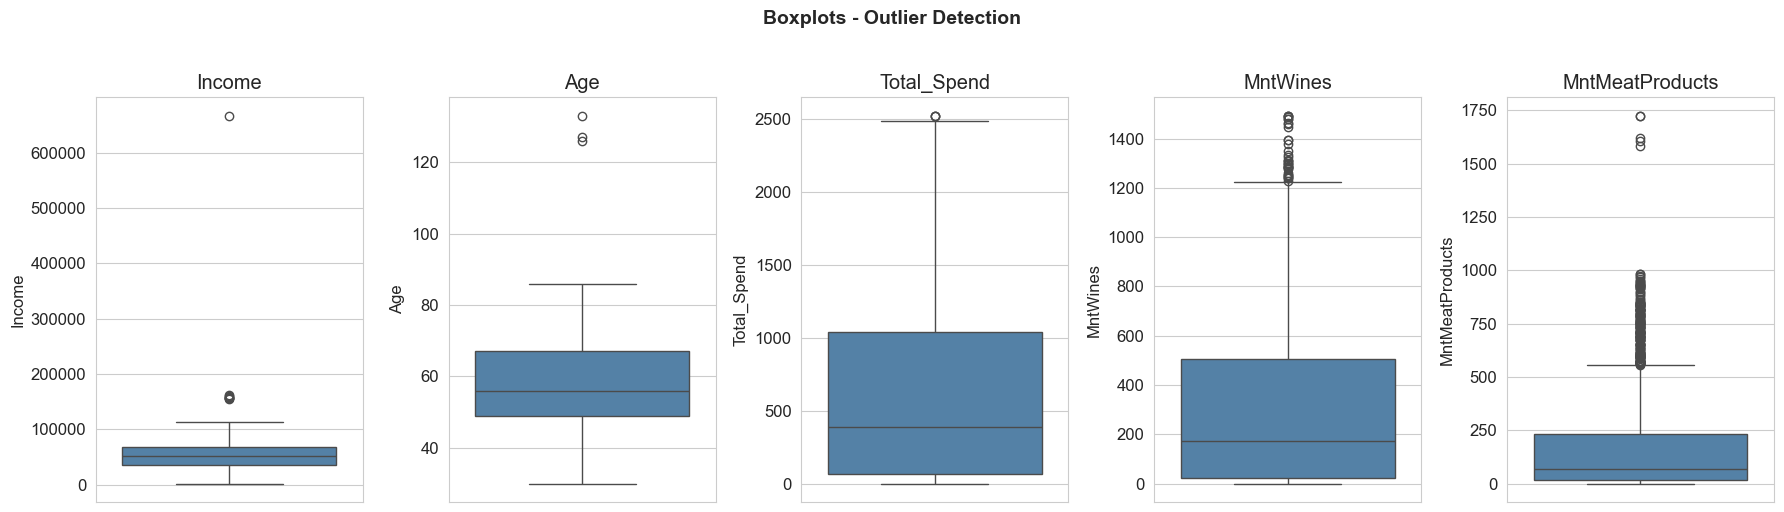

In [134]:
outlier_cols = ['Income', 'Age', 'Total_Spend', 'MntWines', 'MntMeatProducts']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
plt.suptitle('Boxplots - Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8b. Identify and Handle Extreme Outliers

In [135]:
# Check extreme outliers in Income and Age
print('Income outliers (> $200,000):')
print(df[df['Income'] > 200000][['ID', 'Income', 'Age', 'Total_Spend']].to_string())

print(f'\nAge outliers (> 100 years):')
print(df[df['Age'] > 100][['ID', 'Year_Birth', 'Age']].to_string())

# Remove extreme outliers (Income > 200K and Age > 100)
print(f'\nRows before removing outliers: {len(df)}')
df = df[(df['Income'] < 200000) & (df['Age'] < 100)]
print(f'Rows after removing outliers:  {len(df)}')

Income outliers (> $200,000):
        ID    Income  Age  Total_Spend
2233  9432  666666.0   49           62

Age outliers (> 100 years):
        ID  Year_Birth  Age
192   7829        1900  126
239  11004        1893  133
339   1150        1899  127

Rows before removing outliers: 2240
Rows after removing outliers:  2236


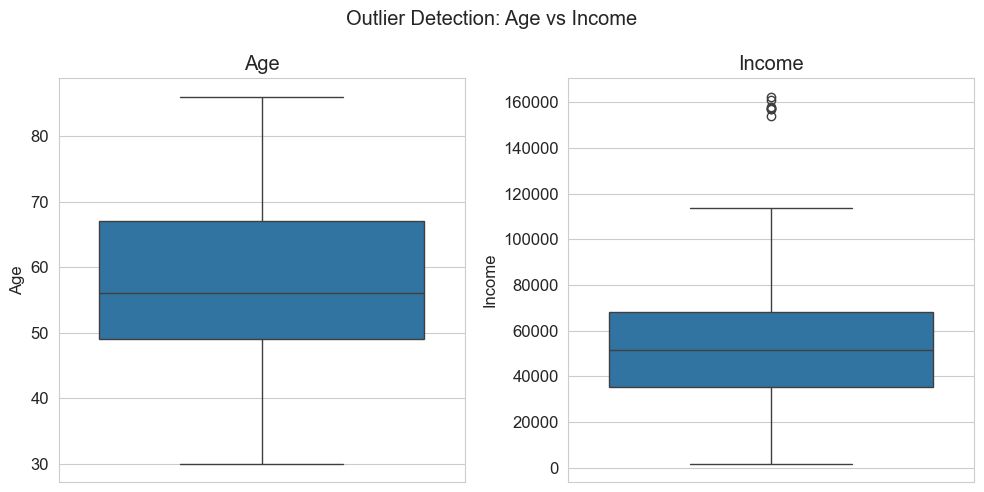

In [136]:
outlier_cols = ['Age', 'Income']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(10,5))

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.suptitle('Outlier Detection: Age vs Income')
plt.tight_layout()
plt.show()

## Step 8c: Clean Categorical Variables

Before diving into analysis, we simplify the categorical columns to reduce noise:
- **Marital Status:** Group into "Partnered" (Married, Together) and "Single" (Single, Divorced, Widow, Alone, Absurd, YOLO)
- **Education:** Group into "Undergraduate" (Basic, 2n Cycle), "Graduate" (Graduation), and "Postgraduate" (Master, PhD)

In [137]:
# Simplify Marital Status into two groups
df['Marital_Status'] = df['Marital_Status'].replace({
    'Married': 'Partnered', 'Together': 'Partnered',
    'Single': 'Single', 'Divorced': 'Single', 'Widow': 'Single',
    'Alone': 'Single', 'Absurd': 'Single', 'YOLO': 'Single'
})

# Simplify Education into three tiers
df['Education'] = df['Education'].replace({
    'Basic': 'Undergraduate', '2n Cycle': 'Undergraduate',
    'Graduation': 'Graduate', 'Master': 'Postgraduate', 'PhD': 'Postgraduate'
})

print('Marital Status after cleaning:')
print(df['Marital_Status'].value_counts())
print('\nEducation after cleaning:')
print(df['Education'].value_counts())

Marital Status after cleaning:
Marital_Status
Partnered    1442
Single        794
Name: count, dtype: int64

Education after cleaning:
Education
Graduate         1126
Postgraduate      855
Undergraduate     255
Name: count, dtype: int64


## Step 9: Univariate Analysis
> **"Looking at one variable at a time"**

### What is Univariate Analysis?

**Uni** = One. **Variate** = Variable.

Univariate analysis means we study **each column individually** — completely on its own, without comparing it to anything else. The only question we ask is:

> *"What does this single variable look like? What is its shape, spread, and center?"*

---

### Simple Real-World Analogy

Imagine you just got a class's exam results. Before comparing scores by gender, age, or study hours — you first just look at the **scores themselves**:
- What was the average score?
- Were most students clustered around 60-70, or spread all over?
- Were there any extreme scores (very low or very high)?

That's univariate analysis. You're learning about **one thing at a time**.

---

### What We Look For

| What to Check | Why It Matters |
|---|---|
| **Shape of the distribution** | Is it bell-shaped (normal) or skewed to one side? |
| **Mean vs Median** | If they differ a lot, the data is skewed (pulled by extreme values) |
| **Range (min/max)** | Helps spot impossible or suspicious values |
| **Spread (std)** | How different are customers from each other? |

---

### Charts We Use
- **Histogram with KDE curve** — shows the shape and frequency of values
- **Bar chart / Count plot** — for categorical columns (Education, Marital Status)
- **Boxplot** — shows median, spread, and outliers at a glance

---

### 9a. Distribution of Numerical Features

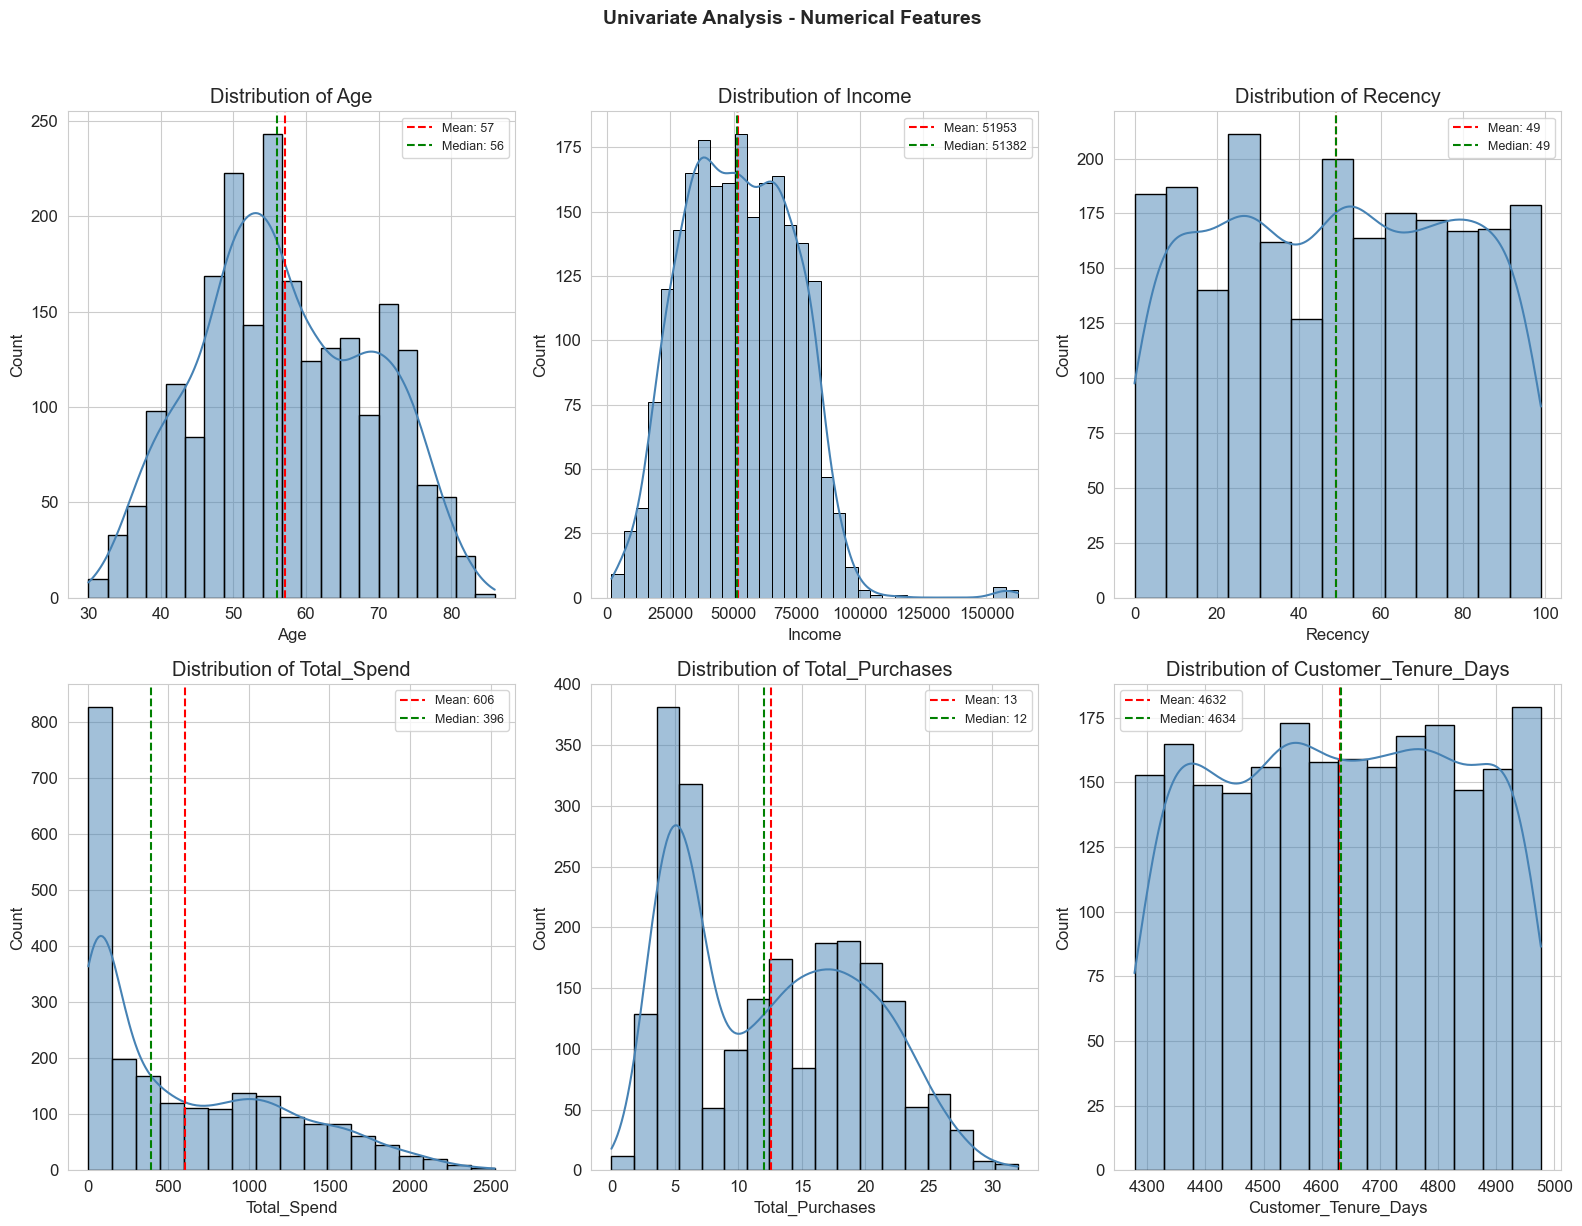

In [138]:
num_features = ['Age', 'Income', 'Recency', 'Total_Spend', 'Total_Purchases', 'Customer_Tenure_Days']

fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.0f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.0f}')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend(fontsize=9)

plt.suptitle('Univariate Analysis - Numerical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### What Do These Distributions Tell Us?

- **Age:** Most customers are between 45–75 years old. The mean and median are close together, so the average age is a reliable number — no extreme skew.
- **Income:** Slightly right-skewed — most earn $30K–$80K, but a few high earners pull the mean above the median. The "average income" is not a perfect picture of a typical customer.
- **Recency:** Nearly flat/uniform — customers are spread evenly across 0–99 days since last purchase. Recency alone won't separate customers into groups.
- **Total_Spend:** Strongly right-skewed — the majority spend below $500, while a small group spends over $1,500. This gap hints at **naturally distinct spending segments**.
- **Total_Purchases:** Roughly bell-shaped, centered around 12–13 purchases. Most customers are moderately active.
- **Customer_Tenure_Days:** Fairly uniform — customers enrolled across a 2-year window, so tenure is spread out.

> **Key Takeaway for Clustering:** The large spread in `Total_Spend` and `Income` means these features will strongly differentiate customer segments.

### 9b. Distribution of Spending by Product Category

#### What Do the Product Distributions Tell Us?

All six product spending columns are **heavily right-skewed** with a large spike at or near zero. This means:
- The **majority of customers spend very little** on each individual product
- A **small but significant group** of high-value customers spends heavily
- **Wines and Meat** have the widest spread — the most "differentiating" product categories

> **Why this matters:** These skewed distributions suggest that a handful of extreme spenders could dominate the clustering. The columns with the widest spread (Wines, Meat) will naturally carry more weight when grouping customers.

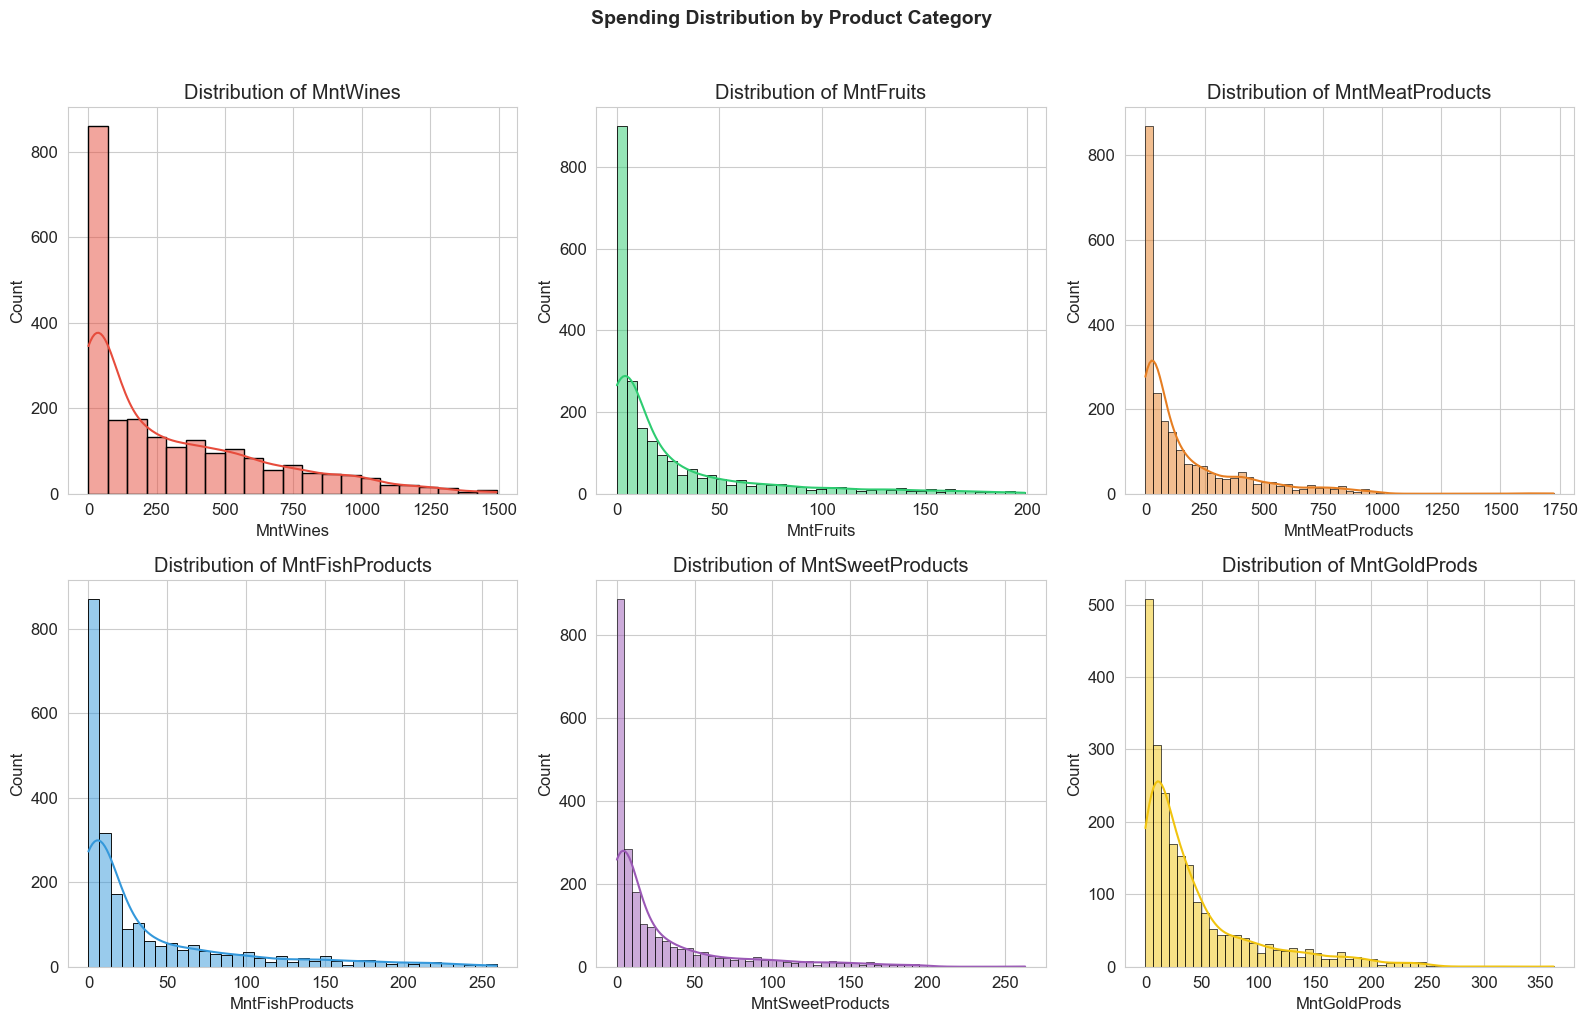

In [139]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db', '#9b59b6', '#f1c40f']

for i, col in enumerate(product_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i], edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')

plt.suptitle('Spending Distribution by Product Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9c. Categorical Features - Education & Marital Status

#### What Do the Categorical Distributions Tell Us?

- **Education:** The majority of customers are Graduates. Postgraduates (Master + PhD) make up a significant portion. Undergraduates (Basic + 2n Cycle) are the smallest group — our customer base is relatively well-educated.
- **Marital Status:** ~65% are Partnered (Married or Together). The remaining ~35% are Single (includes Single, Divorced, Widow, and a few data entry errors like Absurd/YOLO that were grouped here).

> **Key point about Univariate Analysis:** For categorical columns, we are just **counting** — not comparing against anything else yet. We simply learn what our typical customer looks like: a *graduate-level, partnered adult*. Asking "do married customers spend more?" is a bivariate question — that comes next.

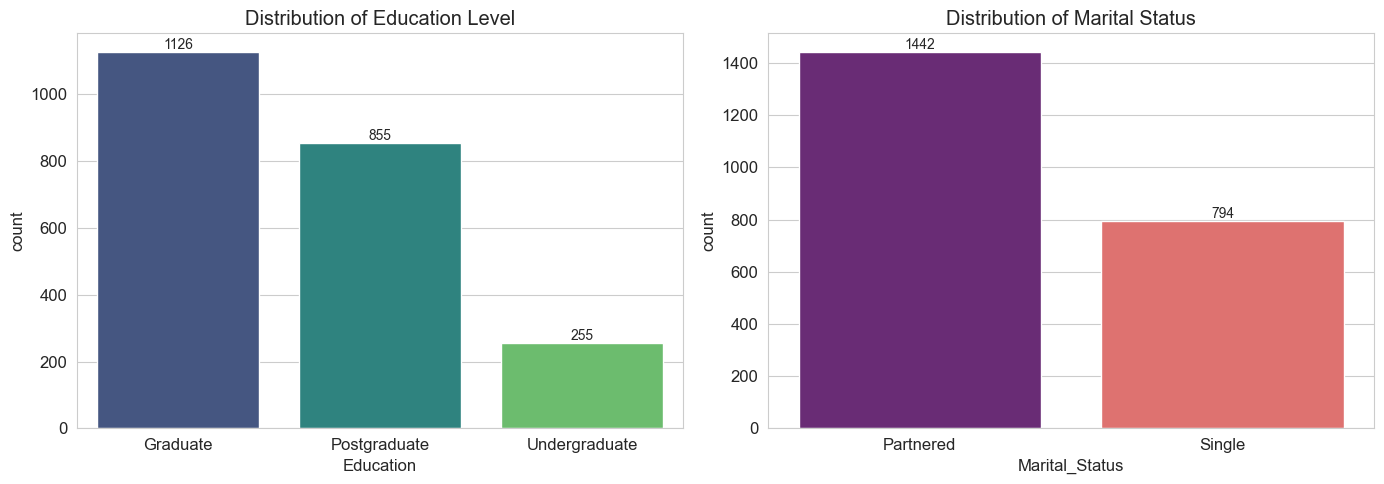

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Education
order_edu = df['Education'].value_counts().index
sns.countplot(x='Education', data=df, order=order_edu, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Education Level')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Marital Status
order_ms = df['Marital_Status'].value_counts().index
sns.countplot(x='Marital_Status', data=df, order=order_ms, ax=axes[1], palette='magma')
axes[1].set_title('Distribution of Marital Status')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 9d. Campaign Acceptance Rates

#### What Do the Campaign Rates Tell Us?

All campaigns have **very low acceptance rates (1–7%)**. Purely univariate observations:
- Campaign 2 had the lowest response (~1.3%) — least effective
- Campaigns 4 and 5 had the best rates (~7.3%)
- The last campaign (Response column) shows ~15% — the highest, suggesting improvement over time

> **Important:** At this stage we are NOT asking "why" some campaigns did better. That question — e.g., "Did higher-income customers accept more?" — belongs to **Bivariate Analysis**. Right now we are just establishing the baseline number for each variable individually.

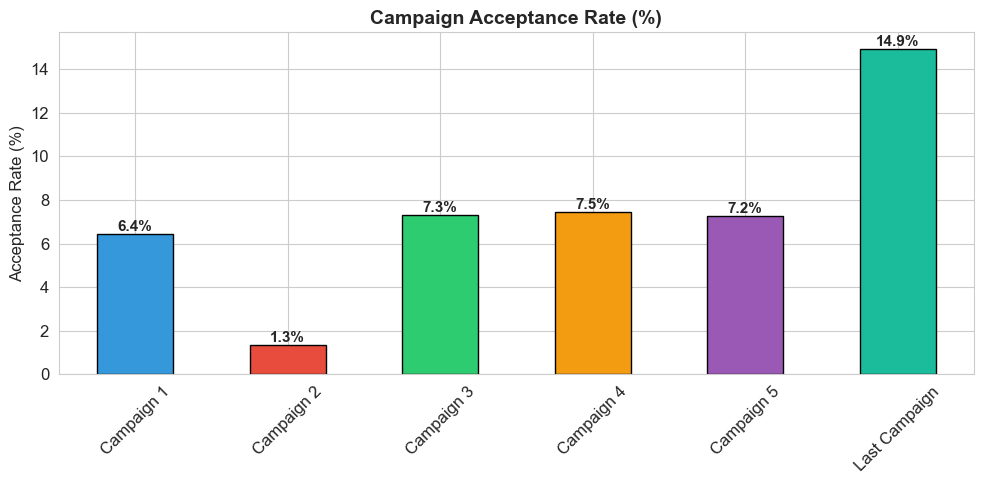

In [141]:
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
campaign_rates = df[campaign_cols].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = campaign_rates.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c'],
                           edgecolor='black', ax=ax)
ax.set_title('Campaign Acceptance Rate (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Acceptance Rate (%)')
ax.set_xticklabels(['Campaign 1', 'Campaign 2', 'Campaign 3', 'Campaign 4', 'Campaign 5', 'Last Campaign'],
                   rotation=45)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
               ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 10: Bivariate Analysis
> **"Looking at two variables together — do they relate to each other?"**

### What is Bivariate Analysis?

**Bi** = Two. **Variate** = Variable.

Bivariate analysis examines **two variables at the same time** to see if there is a **relationship, pattern, or difference** between them. The central question is:

> *"When one variable changes, does the other variable change too?"*

---

### Simple Real-World Analogy

Going back to exam scores — now you want to know: *"Do students who study more hours tend to score higher?"*

You're looking at **two things together**: study hours AND exam scores. That's bivariate analysis.

In our dataset, we ask questions like:
- Do customers with **higher income** spend **more money**?
- Does **education level** affect how much a customer spends?
- Do customers **with children** behave differently from those without?

---

### What We Look For

| Relationship Type | Example | Chart Used |
|---|---|---|
| **Numerical vs Numerical** | Income vs Spending | Scatter plot |
| **Categorical vs Numerical** | Education vs Spending | Box plot |
| **Categorical vs Numerical** | Marital Status vs Income | Box plot |
| **Correlation strength** | Does higher income = higher spending? | Correlation value |

---

### How to Read the Charts

- **Scatter plot:** If dots form a rising diagonal pattern → positive relationship (both go up together)
- **Box plot:** If the boxes for different categories are at different heights → the category affects that value
- **Correlation value:** Ranges from -1 to +1. Close to +1 = strong positive link, close to 0 = no link, close to -1 = negative link

---

### 10a. Income vs Total Spending

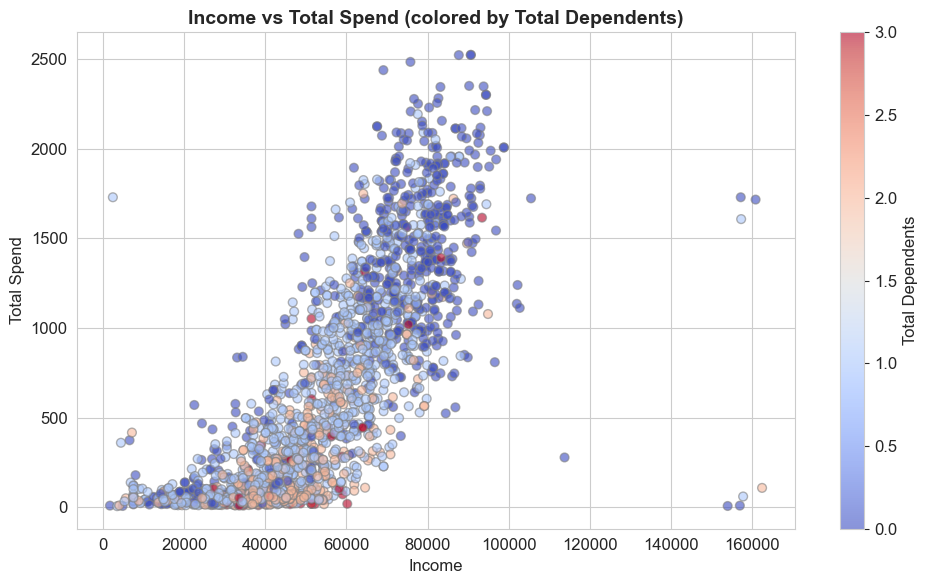

Correlation (Income vs Total Spend): 0.789


In [142]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['Income'], df['Total_Spend'], c=df['Total_Dependents'],
                     cmap='coolwarm', alpha=0.6, edgecolor='gray', s=40)
plt.colorbar(scatter, label='Total Dependents')
ax.set_xlabel('Income')
ax.set_ylabel('Total Spend')
ax.set_title('Income vs Total Spend (colored by Total Dependents)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Correlation (Income vs Total Spend): {df["Income"].corr(df["Total_Spend"]):.3f}')

#### What Does This Scatter Plot Tell Us?

This is a classic bivariate chart — two numerical variables plotted against each other.

- **Rising diagonal pattern** = as income goes up, spending goes up too → **positive relationship**
- The **correlation of ~0.79** is strong — income is one of the best predictors of how much a customer will spend
- The **color coding by dependents** adds a third variable: red/warm dots (more dependents) tend to cluster at the **lower-spending** end even at similar income levels — a preview of multivariate patterns

> **Business Insight:** A high-income customer who spends little is unusual and may be a growth opportunity. A low-income customer who spends a lot relative to their means is a loyal, high-engagement customer.

### 10b. Spending by Education Level

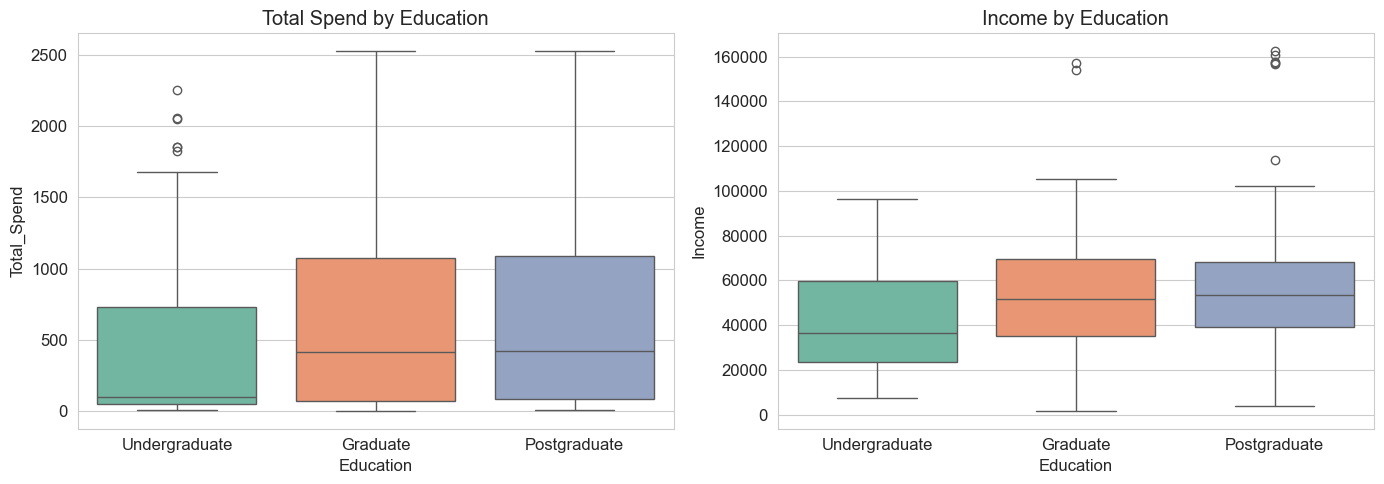

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total spending by education
edu_order = ['Undergraduate', 'Graduate', 'Postgraduate']
sns.boxplot(x='Education', y='Total_Spend', data=df, order=edu_order, ax=axes[0], palette='Set2')
axes[0].set_title('Total Spend by Education')

# Income by education
sns.boxplot(x='Education', y='Income', data=df, order=edu_order, ax=axes[1], palette='Set2')
axes[1].set_title('Income by Education')

plt.tight_layout()
plt.show()

#### What Do These Box Plots Tell Us?

**How to read a box plot:**
- The **middle line** inside the box = median (the "typical" value)
- The **box** = where the middle 50% of customers fall
- The **whiskers** = the normal range
- **Dots beyond the whiskers** = outliers (unusual customers)

**What we see:**
- Education level has **minimal effect on spending** — the medians across all groups are very similar. An Undergraduate can spend just as much as a Postgraduate.
- However, Postgraduate customers have **higher income** on average (right chart).
- The income advantage of postgraduate education doesn't automatically translate into proportionally higher spending.

> **Bivariate Insight:** Education alone is not a strong spending predictor — `Income` is. For clustering, `Income` will carry more predictive weight than `Education`.

### 10c. Spending by Marital Status

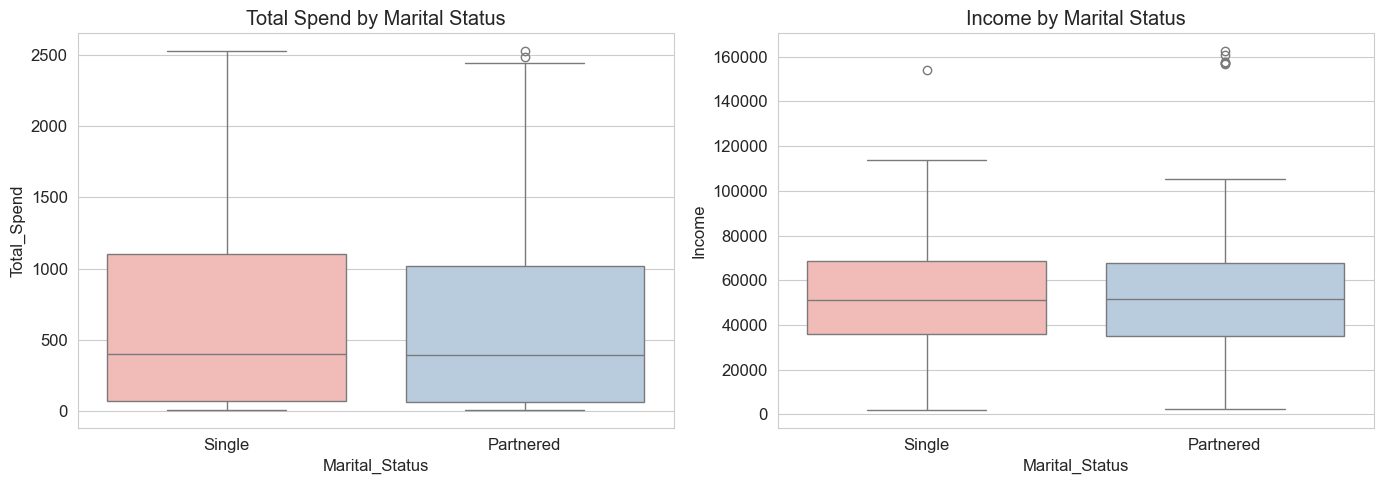

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Marital_Status', y='Total_Spend', data=df, ax=axes[0], palette='Pastel1')
axes[0].set_title('Total Spend by Marital Status')

sns.boxplot(x='Marital_Status', y='Income', data=df, ax=axes[1], palette='Pastel1')
axes[1].set_title('Income by Marital Status')

plt.tight_layout()
plt.show()

#### What Does Marital Status vs Spending Tell Us?

- Partnered and Single customers show **broadly similar spending patterns**
- Single customers show a slightly wider spread — some spend a lot, others very little
- The difference between groups is **not dramatic**, meaning marital status alone is a weak segmentation feature

> **Bivariate Insight:** Marital status is more useful when **combined** with other variables (e.g., income and children) — which is exactly why we progress to multivariate analysis next.

### 10d. Impact of Children on Spending

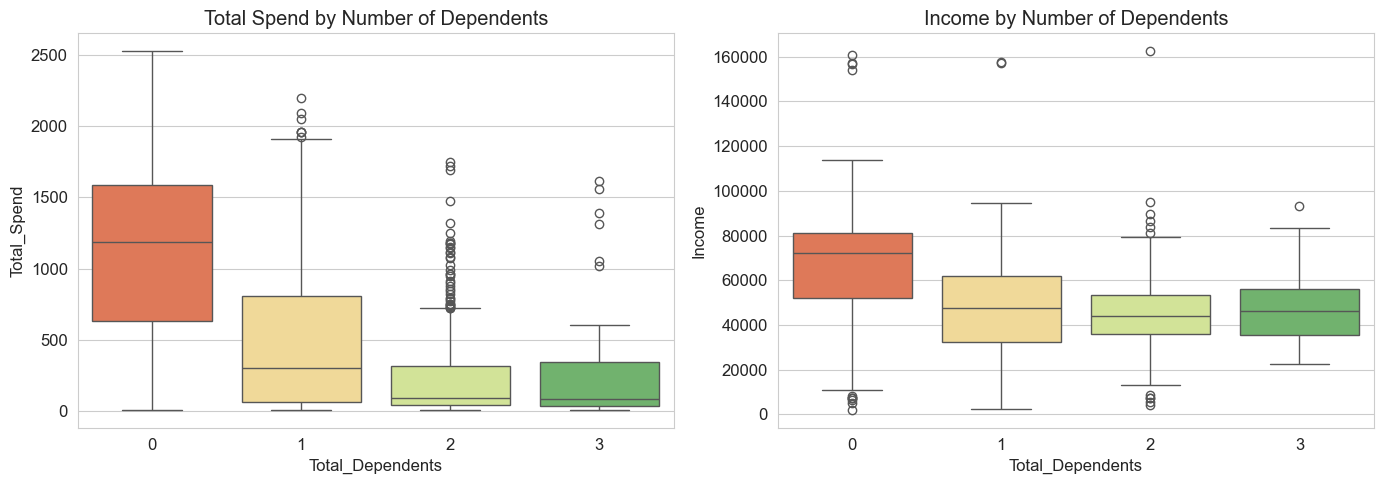

Average spending by number of dependents:
                     mean  median  count
Total_Dependents                        
0                 1104.86  1189.0    637
1                  473.86   306.0   1125
2                  245.95    93.0    421
3                  274.60    88.0     53


In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Total_Dependents', y='Total_Spend', data=df, ax=axes[0], palette='RdYlGn')
axes[0].set_title('Total Spend by Number of Dependents')

sns.boxplot(x='Total_Dependents', y='Income', data=df, ax=axes[1], palette='RdYlGn')
axes[1].set_title('Income by Number of Dependents')

plt.tight_layout()
plt.show()

# Average spending by number of dependents
print('Average spending by number of dependents:')
print(df.groupby('Total_Dependents')['Total_Spend'].agg(['mean', 'median', 'count']).round(2))

#### What Does Dependents vs Spending Tell Us?

This is one of the **strongest bivariate relationships** in the dataset:

- Customers with **0 dependents** spend dramatically more (median ~$1,000+) than those with 1–3 dependents
- As the number of dependents increases, **both spending AND income decrease**
- Customers with 2–3 dependents spend very little on discretionary products like wine and meat

> **Business Insight:** Having children is a powerful behavioral signal. Child-free customers are high-value targets for premium product marketing. Customers with children may respond better to budget-conscious campaigns.

> **For Clustering:** `Total_Dependents` creates very clear separation between customer groups and is a must-include feature.

### 10e. Purchase Channel Comparison

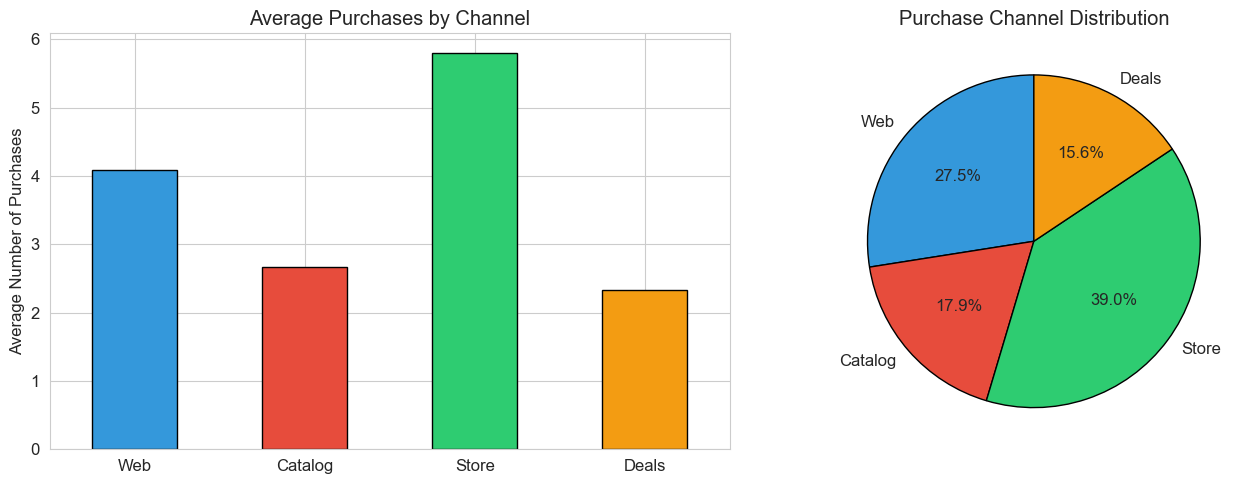

In [146]:
channel_means = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of average purchases per channel
channel_means.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], edgecolor='black')
axes[0].set_title('Average Purchases by Channel')
axes[0].set_xticklabels(['Web', 'Catalog', 'Store', 'Deals'], rotation=0)
axes[0].set_ylabel('Average Number of Purchases')

# Pie chart
axes[1].pie(channel_means, labels=['Web', 'Catalog', 'Store', 'Deals'],
            autopct='%1.1f%%', colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
            startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Purchase Channel Distribution')

plt.tight_layout()
plt.show()

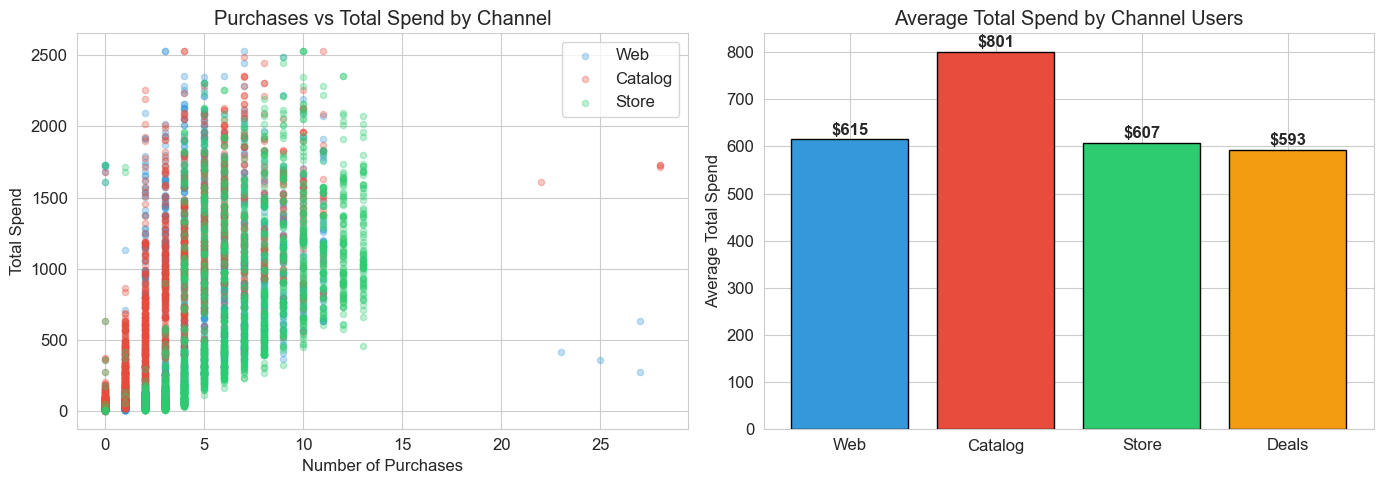

Correlation of each channel with Total Spend:
  Web       : 0.520
  Catalog   : 0.778
  Store     : 0.675
  Deals     : -0.065


In [147]:
# Compare average spending across purchase channels
# Split customers into groups based on their dominant channel
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: each channel's purchase count vs Total Spend
for col, color, label in zip(channel_cols, ['#3498db', '#e74c3c', '#2ecc71'], ['Web', 'Catalog', 'Store']):
    axes[0].scatter(df[col], df['Total_Spend'], alpha=0.3, s=20, color=color, label=label)
axes[0].set_xlabel('Number of Purchases')
axes[0].set_ylabel('Total Spend')
axes[0].set_title('Purchases vs Total Spend by Channel')
axes[0].legend()

# Average spending for customers who use each channel (at least 1 purchase)
avg_spend_by_channel = {
    'Web': df[df['NumWebPurchases'] > 0]['Total_Spend'].mean(),
    'Catalog': df[df['NumCatalogPurchases'] > 0]['Total_Spend'].mean(),
    'Store': df[df['NumStorePurchases'] > 0]['Total_Spend'].mean(),
    'Deals': df[df['NumDealsPurchases'] > 0]['Total_Spend'].mean()
}

bars = axes[1].bar(avg_spend_by_channel.keys(), avg_spend_by_channel.values(),
                   color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], edgecolor='black')
axes[1].set_title('Average Total Spend by Channel Users')
axes[1].set_ylabel('Average Total Spend')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
                 f'${bar.get_height():.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print the correlation between each channel and Total Spend
print('Correlation of each channel with Total Spend:')
for col, label in zip(channel_cols + ['NumDealsPurchases'], ['Web', 'Catalog', 'Store', 'Deals']):
    print(f'  {label:10s}: {df[col].corr(df["Total_Spend"]):.3f}')

#### What Does the Channel Comparison Tell Us?

- **Store purchases** are the most common channel — customers prefer in-person shopping
- **Web purchases** are second — digital is significant but not dominant
- **Catalog purchases** are the least common channel, but catalog users have the **highest average spending** — they are premium buyers
- **Deal purchases** are moderate — deal-seekers tend to have lower total spending

> **Bivariate Insight:** The channel a customer uses is clearly linked to their spending level. Catalog shoppers spend significantly more on average than web or store shoppers. This pattern only emerges when we compare channels against spending — a purely univariate view (just counting purchases) would miss this entirely.

## Step 11: Multivariate Analysis
> **"Looking at three or more variables together — the full picture"**

### What is Multivariate Analysis?

**Multi** = Many. **Variate** = Variable.

Multivariate analysis looks at **three or more variables simultaneously** to understand complex patterns that you simply cannot see by looking at one or two variables at a time. The question becomes:

> *"How do multiple variables interact with each other all at once?"*

---

### Simple Real-World Analogy

Now for exam scores, you ask: *"Do students who study more hours, sleep better, AND attend more classes tend to score higher — and how do all these factors relate to each other?"*

You're juggling **many things at once**. In our data:
- How does Income relate to Spending AND Age AND Dependents all together?
- Which features are strongly linked to each other, and which are independent?
- Are there groups of features that move together?

---

### Why This Matters for Clustering

Customer segmentation (clustering) is inherently multivariate — the algorithm considers **all features simultaneously** to group customers. Multivariate analysis helps us:
1. **Identify redundant features** — if two features are almost identical, we only need one
2. **Understand the feature space** — see the "shape" of the data before clustering
3. **Spot natural groupings** — patterns that suggest customer segments exist

---

### Charts We Use

| Chart | What It Shows |
|---|---|
| **Correlation Heatmap** | All pairwise relationships between every numerical column at once |
| **Horizontal Bar (Top Correlations)** | Which features have the strongest link to Total Spend |
| **Pairplot** | Every possible scatter plot combination of selected features in one grid |

---

### How to Read a Correlation Heatmap
- Each cell shows the correlation between the **row variable** and **column variable**
- **Dark red → close to +1** = strong positive relationship (both rise together)
- **Dark blue → close to -1** = strong negative relationship (one rises, other falls)
- **White/light → close to 0** = little to no relationship

---

### 11a. Correlation Heatmap

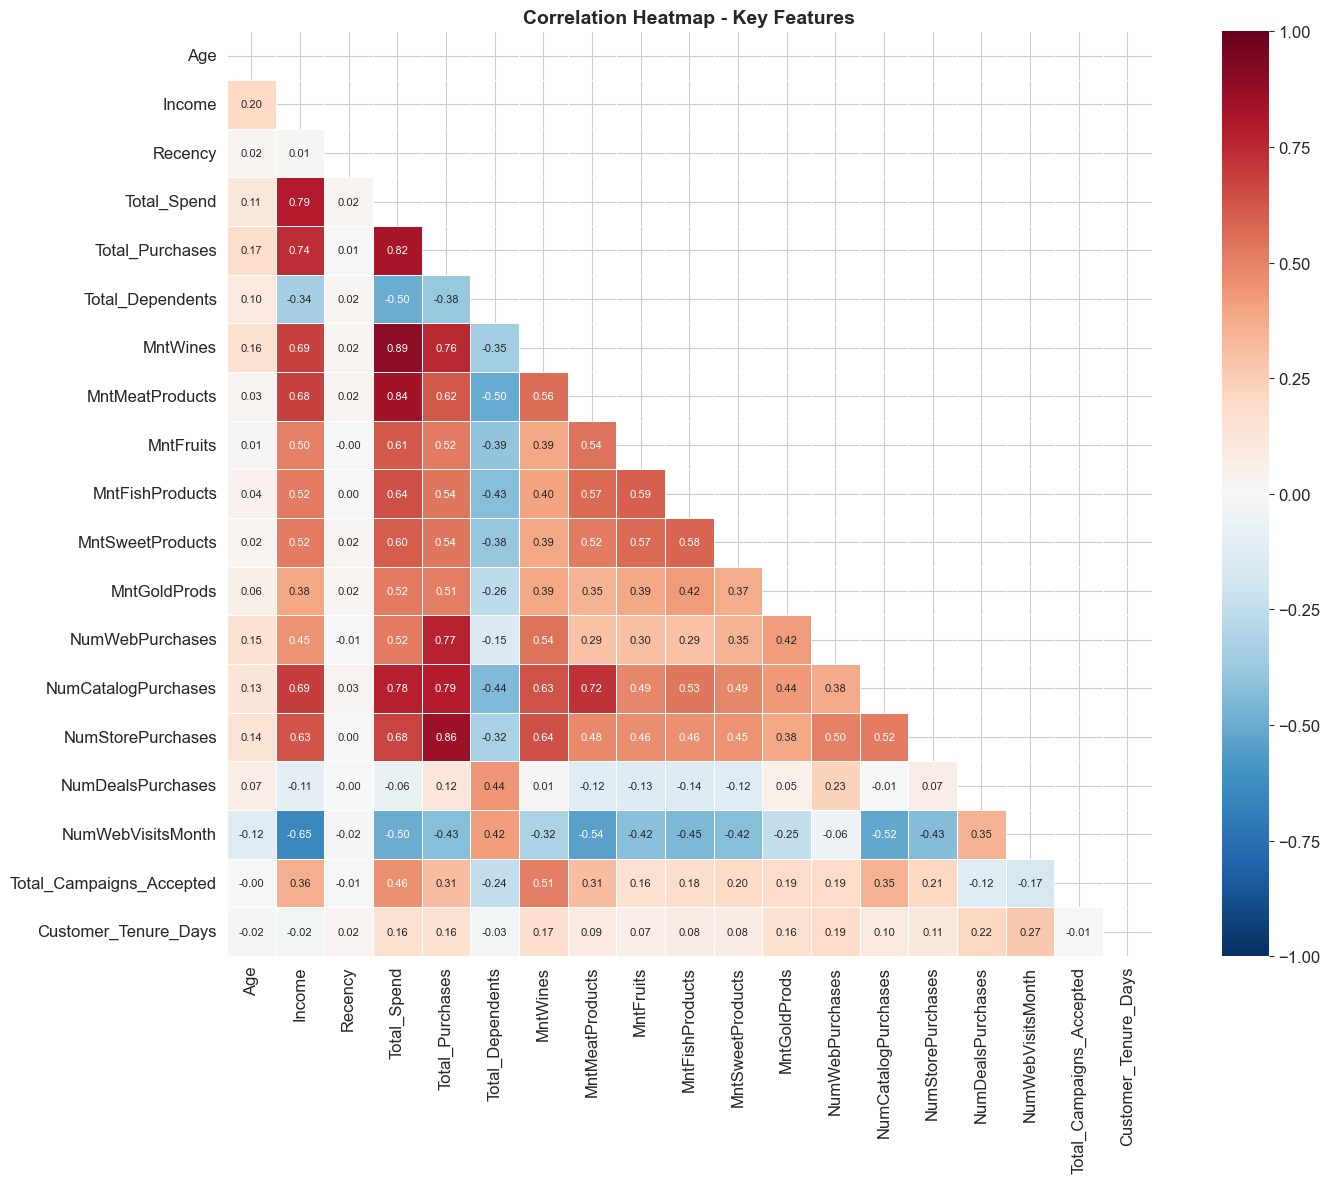

In [148]:
# Select key numerical columns for correlation
corr_cols = ['Age', 'Income', 'Recency', 'Total_Spend', 'Total_Purchases', 'Total_Dependents',
             'MntWines', 'MntMeatProducts', 'MntFruits', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
             'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases',
             'NumWebVisitsMonth', 'Total_Campaigns_Accepted', 'Customer_Tenure_Days']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap - Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### How to Read This Heatmap — Key Patterns

This single chart shows the relationship between **every pair of variables simultaneously** — impossible to see in univariate or bivariate analysis alone.

**Strong Positive Correlations (dark red):**
- `Income` ↔ `Total_Spend` (~0.79) — confirmed from bivariate analysis, now seen in full context
- `MntWines` ↔ `Total_Spend` and `Income` — wine spending tracks strongly with overall wealth
- `NumCatalogPurchases` ↔ `MntMeatProducts` — catalog shoppers buy a lot of meat

**Strong Negative Correlations (dark blue):**
- `Total_Dependents` ↔ `Total_Spend`, `Income`, `MntWines` — dependents consistently suppress spending across all categories
- `NumWebVisitsMonth` ↔ `Income` and `Total_Spend` — frequent web visitors who don't buy tend to have lower income

**Near-Zero Correlations (white/light):**
- `Recency` shows almost no relationship with anything — how recently someone bought does NOT predict how much they spend

> **Multivariate Insight:** `Income`, `Total_Dependents`, and `Total_Spend` form a tight cluster of related features. For clustering, all three together may create redundancy — we may only need one or two to capture the same information.

### 11b. Top Correlations with Total Spend

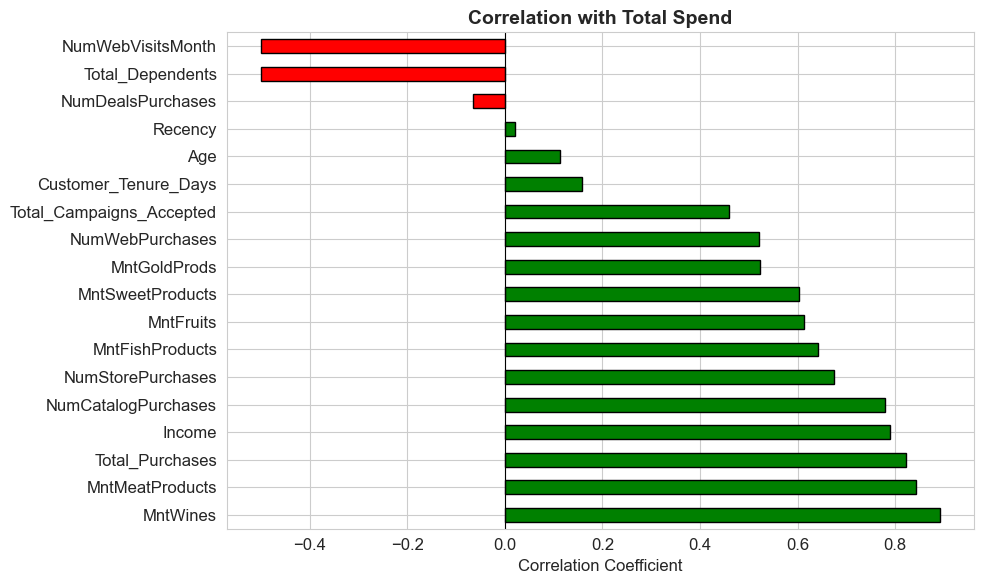

In [149]:
# Top correlations with Total_Spend
spending_corr = corr_matrix['Total_Spend'].drop('Total_Spend').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in spending_corr]
spending_corr.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
ax.set_title('Correlation with Total Spend', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

#### What Do the Top Correlations Tell Us?

**Green bars (positive)** — when these increase, Total Spend increases:
- `MntWines`, `MntMeatProducts`, `NumCatalogPurchases`, `Income` are the top predictors of high spending

**Red bars (negative)** — when these increase, Total Spend decreases:
- `Total_Dependents` and `NumWebVisitsMonth` — more dependents and casual web browsing = lower spending
- `NumDealsPurchases` — deal-seekers tend to be budget-conscious, lower-spend customers

> **This chart is multivariate** because we're simultaneously ranking all features by their relationship to one target — impossible to see from bivariate charts alone.

> **For Feature Selection:** Features with correlation close to zero (like `Recency`, `Customer_Tenure_Days`) contribute little to predicting spending and may add noise to clustering.

### 11c. Pairplot - Key Features

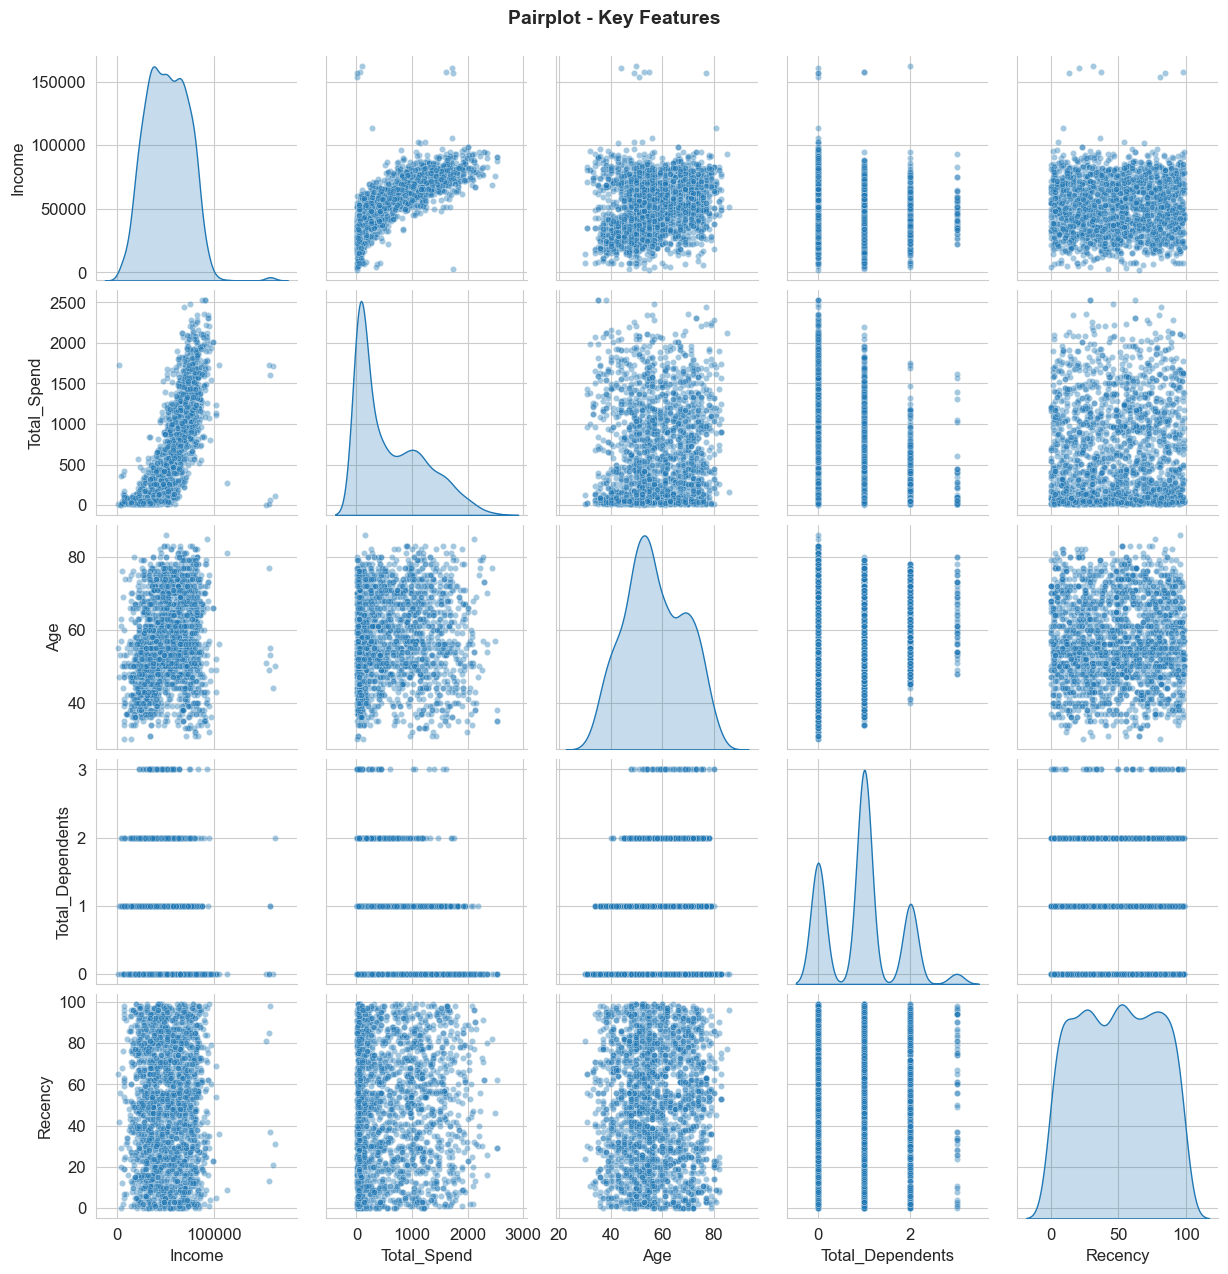

In [150]:
pair_cols = ['Income', 'Total_Spend', 'Age', 'Total_Dependents', 'Recency']

sns.pairplot(df[pair_cols], diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20})
plt.suptitle('Pairplot - Key Features', fontsize=14, fontweight='bold', y=1.02)
plt.show()

#### How to Read the Pairplot

A **pairplot** is a grid of scatter plots and distribution curves. Each row/column represents one variable. Every cell shows the relationship between the row variable and the column variable.

- **Diagonal cells** = distribution of a single variable (KDE curve) → **univariate view**
- **Off-diagonal cells** = scatter plots of two variables → **bivariate view**
- **All together in one grid** → **multivariate view**

**Key patterns visible here:**
- `Income` vs `Total_Spend` — clear upward diagonal cloud → strong positive relationship
- `Total_Dependents` vs `Income` — downward cloud → more dependents = lower income
- `Total_Dependents` vs `Total_Spend` — strong downward pattern, confirmed again
- `Age` — little consistent pattern against other variables; age alone doesn't determine spending
- `Recency` — randomly scattered against everything, confirming it is not a useful predictor

> **The Pairplot is the most "multivariate" chart here** — you see 5 variables interacting all at once. No single bivariate chart could show this full picture.

---

### Summary: Uni vs Bi vs Multivariate at a Glance

| Analysis Type | Variables | Question Asked | Example from Our Data |
|---|---|---|---|
| **Univariate** | 1 | "What does this variable look like?" | What is the distribution of Income? |
| **Bivariate** | 2 | "Do these two relate to each other?" | Do higher-income customers spend more? |
| **Multivariate** | 3+ | "How do many variables interact at once?" | Which features collectively predict spending? |

## Step 12: Product Spending Breakdown

How much do customers spend across different product categories?

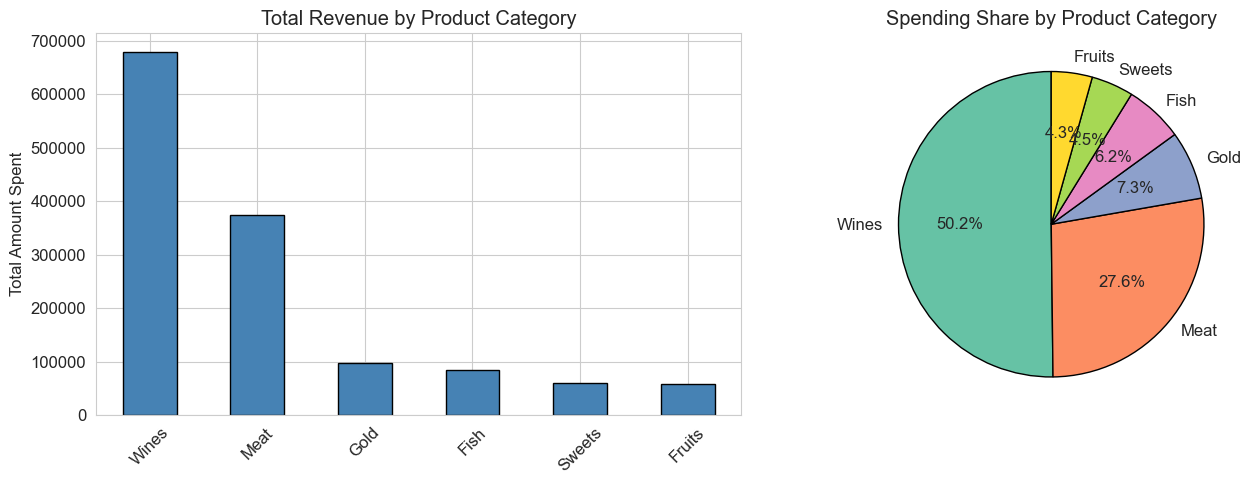

Average spending per customer by product:
MntWines            304.13
MntMeatProducts     166.98
MntGoldProds         43.98
MntFishProducts      37.54
MntSweetProducts     27.08
MntFruits            26.28
dtype: float64


In [151]:
# Total and average spending by category
product_spending = df[product_cols].sum().sort_values(ascending=False)
product_labels = ['Wines', 'Meat', 'Gold', 'Fish', 'Sweets', 'Fruits']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
product_spending.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total Revenue by Product Category')
axes[0].set_ylabel('Total Amount Spent')
axes[0].set_xticklabels(product_labels, rotation=45)

# Pie chart
axes[1].pie(product_spending, labels=product_labels, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Spending Share by Product Category')

plt.tight_layout()
plt.show()

print('Average spending per customer by product:')
print(df[product_cols].mean().sort_values(ascending=False).round(2))

#### What Does the Product Spending Breakdown Tell Us?

- **Wine is the dominant category** — accounting for roughly 50% of all customer spending. This single product drives half the business revenue.
- **Meat is second** at ~25%, making Wine + Meat together responsible for about 75% of total spending
- **Gold, Fish, Sweets, and Fruits** each contribute a relatively small share
- The gap between the top two categories and the rest is significant — this is not an evenly distributed product portfolio

> **Business Insight:** The company is heavily dependent on Wine and Meat sales. Any customer segment that over-indexes on these two categories represents a high-value target. Conversely, customers who primarily buy Fruits or Sweets are likely lower-value.

## Step 13: Customer Demographics Deep Dive

### 13a. Age Distribution by Segments

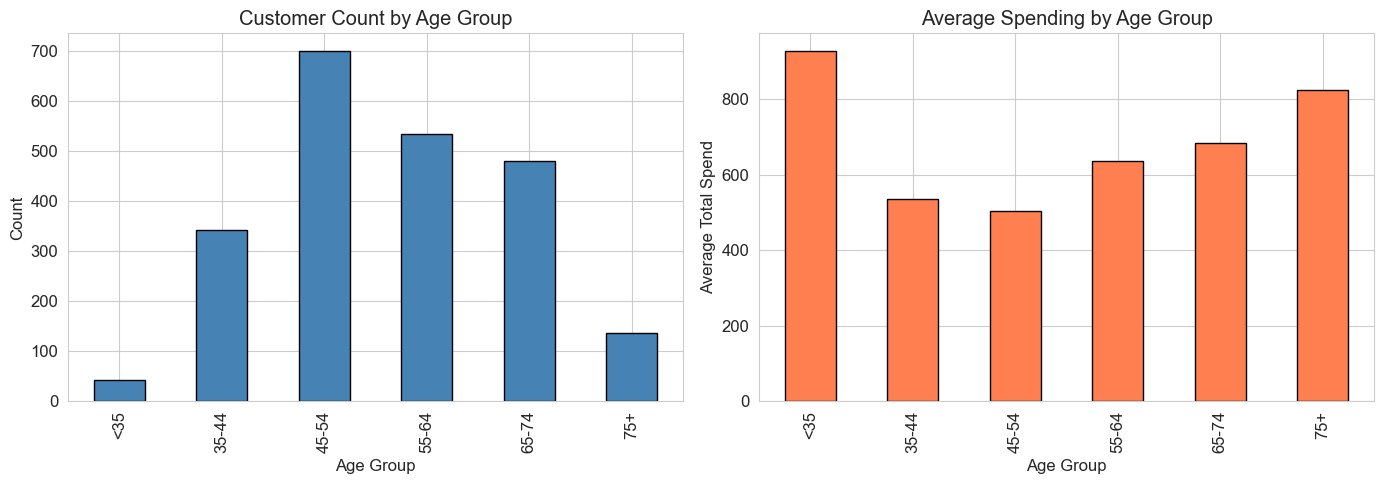

In [152]:
# Create temporary age groups for plotting
bins = [0, 35, 45, 55, 65, 75, 130]
labels = ['<35', '35-44', '45-54', '55-64', '65-74', '75+']
age_group_temp = pd.cut(df['Age'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age group counts
age_group_temp.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Customer Count by Age Group')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Age Group')

# Average spending by age group
df.assign(Age_Group_Temp=age_group_temp).groupby('Age_Group_Temp')['Total_Spend'].mean().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Average Spending by Age Group')
axes[1].set_ylabel('Average Total Spend')
axes[1].set_xlabel('Age Group')

plt.tight_layout()
plt.show()

#### What Does the Age Segmentation Tell Us?

- The **45–64 age range** dominates the customer base — these are the core customers
- Average spending is relatively **consistent across age groups** — unlike income or dependents, age alone is not a strong spending predictor
- The youngest group (<35) and oldest group (75+) are the smallest segments

> **For Clustering:** Age may play a supporting role in defining segments, but it's not as powerful a differentiator as Income or Total Dependents. The clustering algorithm will determine how much weight age actually carries.

### 13b. Income Distribution by Segments

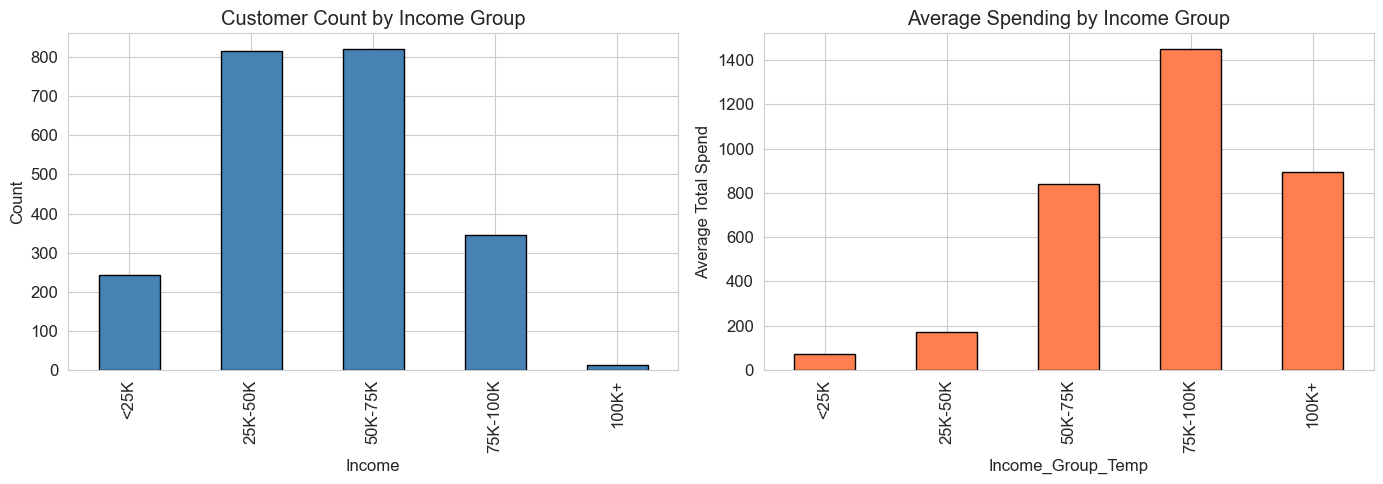

In [153]:
# Create temporary income groups for plotting
income_bins = [0, 25000, 50000, 75000, 100000, 200000]
income_labels = ['<25K', '25K-50K', '50K-75K', '75K-100K', '100K+']
income_group_temp = pd.cut(df['Income'], bins=income_bins, labels=income_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

income_group_temp.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Customer Count by Income Group')
axes[0].set_ylabel('Count')

df.assign(Income_Group_Temp=income_group_temp).groupby('Income_Group_Temp')['Total_Spend'].mean().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Average Spending by Income Group')
axes[1].set_ylabel('Average Total Spend')

plt.tight_layout()
plt.show()

#### What Does the Income Segmentation Tell Us?

- The **25K–50K** and **50K–75K** groups are the largest — most customers fall in the middle-income range
- Average spending scales almost linearly with income group — **100K+ customers spend 3–4x more** than those under 25K
- Very few customers earn above 100K, but they are disproportionately valuable in terms of spending

> **For Clustering:** Income groups create natural tiers, but using raw Income values (continuous) will give the clustering algorithm more flexibility than these discrete bins.

## Step 14: Campaign Response Analysis

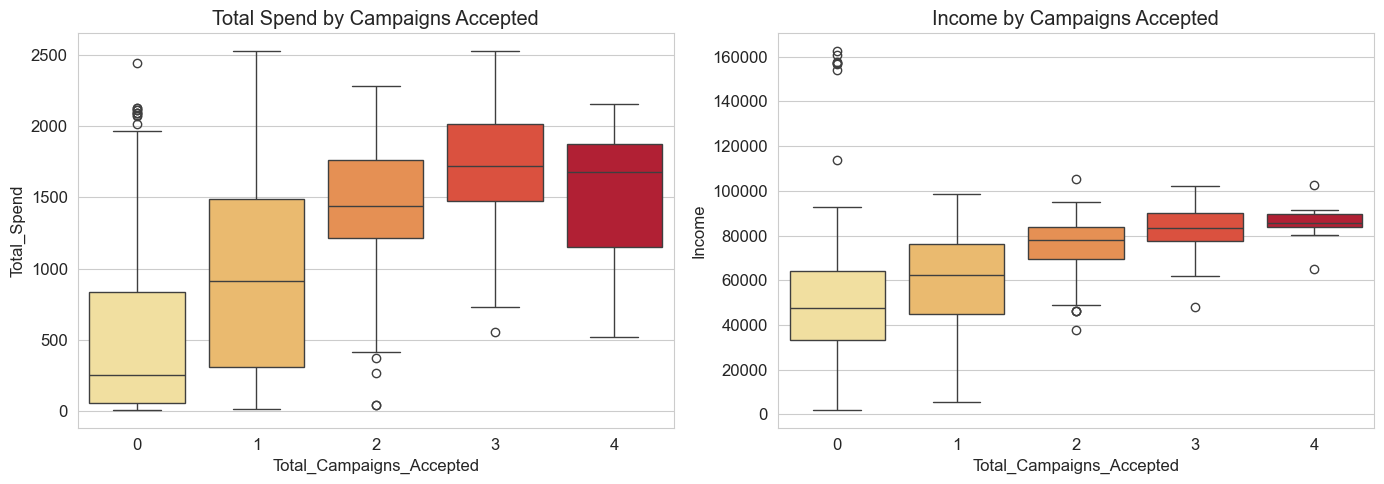


Customer profile by campaign acceptance:
                            Income  Total_Spend    Age  Total_Dependents
Total_Campaigns_Accepted                                                
0                         48529.73       478.53  56.93              1.03
1                         59398.48       918.65  58.57              0.74
2                         75158.11      1408.05  56.63              0.46
3                         82877.27      1705.64  54.52              0.23
4                         85861.64      1501.64  55.73              0.18


In [154]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spending by total campaigns accepted
sns.boxplot(x='Total_Campaigns_Accepted', y='Total_Spend', data=df, ax=axes[0], palette='YlOrRd')
axes[0].set_title('Total Spend by Campaigns Accepted')

# Income by total campaigns accepted
sns.boxplot(x='Total_Campaigns_Accepted', y='Income', data=df, ax=axes[1], palette='YlOrRd')
axes[1].set_title('Income by Campaigns Accepted')

plt.tight_layout()
plt.show()

print('\nCustomer profile by campaign acceptance:')
print(df.groupby('Total_Campaigns_Accepted')[['Income', 'Total_Spend', 'Age', 'Total_Dependents']].mean().round(2))

#### What Does the Campaign Response Analysis Tell Us?

- Customers who accept **more campaigns** have noticeably **higher income and higher spending** — the boxplots show a clear upward trend from 0 to 4 campaigns accepted
- Customers who accepted **zero campaigns** form the largest group and have the lowest median spending
- The few customers who accepted 3–4 campaigns are the **highest-value segment** — high income, high spend, and fewer dependents on average

> **Business Insight:** Campaign responsiveness is strongly linked to customer value. These high-response customers are likely your most engaged, premium segment — exactly the kind of pattern clustering should identify.

## Step 15: Skewness Check

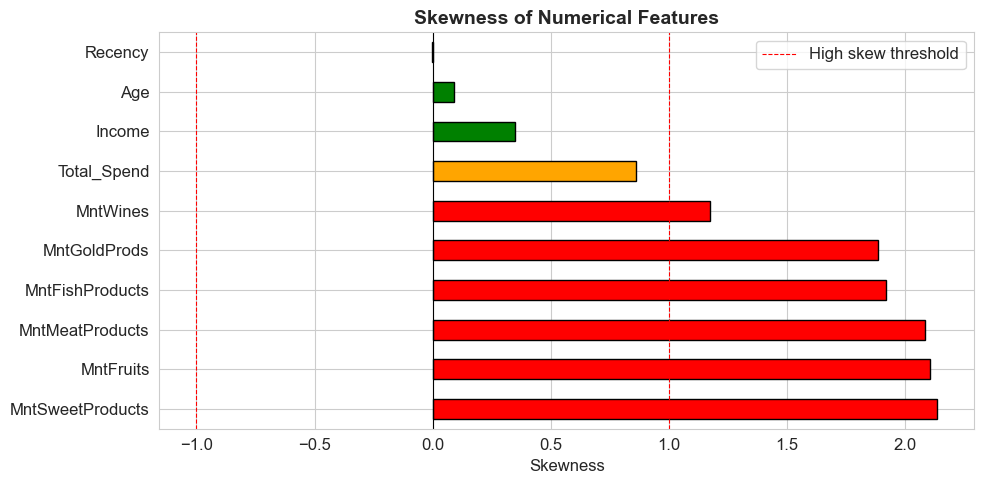


Skewness values:
  MntSweetProducts    : +2.136  (HIGH)
  MntFruits           : +2.104  (HIGH)
  MntMeatProducts     : +2.085  (HIGH)
  MntFishProducts     : +1.920  (HIGH)
  MntGoldProds        : +1.885  (HIGH)
  MntWines            : +1.176  (HIGH)
  Total_Spend         : +0.860  (Moderate)
  Income              : +0.351  (OK)
  Age                 : +0.092  (OK)
  Recency             : -0.004  (OK)


In [155]:
skew_cols = ['Income', 'Total_Spend', 'MntWines', 'MntFruits', 'MntMeatProducts',
             'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'Age', 'Recency']

skewness = df[skew_cols].skew().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red' if abs(x) > 1 else 'orange' if abs(x) > 0.5 else 'green' for x in skewness]
skewness.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
ax.set_title('Skewness of Numerical Features', fontsize=14, fontweight='bold')
ax.set_xlabel('Skewness')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=1, color='red', linewidth=0.8, linestyle='--', label='High skew threshold')
ax.axvline(x=-1, color='red', linewidth=0.8, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()

print('\nSkewness values:')
for col, val in skewness.items():
    status = 'HIGH' if abs(val) > 1 else 'Moderate' if abs(val) > 0.5 else 'OK'
    print(f'  {col:20s}: {val:+.3f}  ({status})')

#### What Does the Skewness Check Tell Us?

- **Highly skewed features** (red bars, |skewness| > 1): `MntFruits`, `MntSweetProducts`, `MntFishProducts`, `MntMeatProducts`, `MntGoldProds` — these have many low-value customers and a long tail of high spenders
- **Moderately skewed** (orange, |skewness| > 0.5): `Income`, `Total_Spend`, `MntWines`
- **Low skew** (green): `Age`, `Recency` — these are relatively symmetric

> **Why this matters for clustering:** K-Means assumes roughly spherical clusters, so highly skewed features can distort results. During the Model Building phase, we will apply **StandardScaler** to normalize these features. For extremely skewed columns, a **log transformation** may also help create more balanced distributions before clustering.

## Step 16: Constant / Low-Variance Columns Check

In [156]:
# Check columns with zero or very low variance
print('Columns with constant values (zero variance):')
for col in df.select_dtypes(include=np.number).columns:
    if df[col].nunique() <= 1:
        print(f'  {col}: unique value = {df[col].unique()}')
    elif df[col].std() == 0:
        print(f'  {col}: std = 0')

print(f'\nZ_CostContact unique values: {df["Z_CostContact"].unique()}  -->  Constant, can be dropped')
print(f'Z_Revenue unique values:     {df["Z_Revenue"].unique()}  -->  Constant, can be dropped')
print(f'\nComplain value counts:\n{df["Complain"].value_counts()}')

Columns with constant values (zero variance):
  Z_CostContact: unique value = [3]
  Z_Revenue: unique value = [11]

Z_CostContact unique values: [3]  -->  Constant, can be dropped
Z_Revenue unique values:     [11]  -->  Constant, can be dropped

Complain value counts:
Complain
0    2216
1      20
Name: count, dtype: int64


## Step 17: Encoding

Before applying machine learning algorithms like clustering, we need to convert categorical variables into numerical format. This step is crucial because clustering algorithms work with numerical data and distance calculations.

### 17a. Encoding Strategy

Our dataset contains two categorical variables that need encoding:

**Education** (Ordinal Variable):
- Has a natural order: Undergraduate → Graduate → Postgraduate
- We'll use Ordinal Encoding to preserve this hierarchy
- This maintains the meaningful relationship between education levels

**Marital_Status** (Nominal Variable):
- No inherent order between categories
- We'll use Binary Encoding (Single=0, Partnered=1) for simplicity
- This reduces complexity while capturing the key distinction

**Why This Matters:**
- Clustering algorithms calculate distances between data points
- Categorical variables must be numeric for distance computations
- Proper encoding preserves the information content of categorical features

### 17b. Encoding Implementation

In [157]:
from sklearn.preprocessing import OrdinalEncoder

# Define encoding maps
education_map = {'Undergraduate': 0, 'Graduate': 1, 'Postgraduate': 2}
marital_map = {'Single': 0, 'Partnered': 1}

# Ordinal encoding for Education (preserving order)
edu_order = ['Undergraduate', 'Graduate', 'Postgraduate']
ord_enc = OrdinalEncoder(categories=[edu_order])

df['Education'] = ord_enc.fit_transform(df[['Education']]).astype(int)

# Binary encoding for Marital Status
df['Marital_Status'] = df['Marital_Status'].map(marital_map)

# Print encoding summary
print('Encoding applied:')
print(f'  Education      — Ordinal encoding: {dict(zip(edu_order, range(len(edu_order))))}')
print(f'  Marital_Status — Binary encoding: {marital_map}')

Encoding applied:
  Education      — Ordinal encoding: {'Undergraduate': 0, 'Graduate': 1, 'Postgraduate': 2}
  Marital_Status — Binary encoding: {'Single': 0, 'Partnered': 1}


## Step 18: Feature Selection for Clustering

Not all features are equally useful for customer segmentation. We need to select the most relevant features that capture customer behavior and demographics while removing noise.

### 18a. Feature Selection Strategy

**Features to KEEP** (9 features for clustering):
- **Demographics**: `Income`, `Age`, `Education_Encoded`, `Marital_Status_Encoded`
- **Behavior**: `Total_Spend`, `Total_Purchases`, `Recency`
- **Engagement**: `Total_Campaigns_Accepted`, `Total_Dependents`

**Features to DROP** (20+ features removed):
- **Identifiers**: `ID` (unique, no clustering value)
- **Raw timestamps**: `Year_Birth`, `Dt_Customer` (converted to Age/Tenure)
- **Component features**: Individual product spends, purchase channels (aggregated into totals)
- **Constants**: `Z_CostContact`, `Z_Revenue` (same value for all)
- **Low variance**: `Complain` (99% zeros)
- **Redundant**: `Kidhome`, `Teenhome` (combined into Total_Dependents)

**Why This Selection?**
- Focuses on behavioral and demographic patterns
- Reduces dimensionality for better clustering performance
- Removes noise and irrelevant features
- Balances interpretability with predictive power

### 18b. Feature Selection Implementation

In [158]:
# Drop redundant, constant, and identifier columns
columns_to_drop = [
    'ID',
    'Year_Birth',
    'Dt_Customer',
    'Kidhome',
    'Teenhome',
    'Z_CostContact',
    'Z_Revenue',
    'Complain',
    'Is_Parent',

    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',

    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds',

    'NumWebPurchases','NumCatalogPurchases','NumStorePurchases'
]

df_model = df.drop(columns=columns_to_drop)

print(f'Columns dropped: {len(columns_to_drop)}')
print(f'Final feature set: {df_model.shape[1]} columns x {df_model.shape[0]} rows')
print("\nFeatures for clustering:")
print(df_model.columns.tolist())

Columns dropped: 23
Final feature set: 13 columns x 2236 rows

Features for clustering:
['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Response', 'Age', 'Total_Spend', 'Total_Purchases', 'Total_Dependents', 'Total_Campaigns_Accepted', 'Customer_Tenure_Days']


In [159]:
# Quick look at the final modeling-ready dataset
print('Final Dataset Summary:')
print(df_model.describe().T.round(2))
print(f'\nData types:')
print(df_model.dtypes)
print(f'\nMissing values: {df_model.isnull().sum().sum()}')
df_model.head(10)

Final Dataset Summary:
                           count      mean       std     min       25%  \
Education                 2236.0      1.27      0.65     0.0      1.00   
Marital_Status            2236.0      0.64      0.48     0.0      0.00   
Income                    2236.0  51952.61  21411.47  1730.0  35502.50   
Recency                   2236.0     49.12     28.96     0.0     24.00   
NumDealsPurchases         2236.0      2.33      1.93     0.0      1.00   
NumWebVisitsMonth         2236.0      5.32      2.43     0.0      3.00   
Response                  2236.0      0.15      0.36     0.0      0.00   
Age                       2236.0     57.10     11.70    30.0     49.00   
Total_Spend               2236.0    605.99    601.87     5.0     69.00   
Total_Purchases           2236.0     12.55      7.21     0.0      6.00   
Total_Dependents          2236.0      0.95      0.75     0.0      0.00   
Total_Campaigns_Accepted  2236.0      0.30      0.68     0.0      0.00   
Customer_Tenure

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Response,Age,Total_Spend,Total_Purchases,Total_Dependents,Total_Campaigns_Accepted,Customer_Tenure_Days
0,1,0,58138.0,58,3,7,1,69,1617,22,0,0,4941
1,1,0,46344.0,38,2,5,0,72,27,4,2,0,4391
2,1,1,71613.0,26,1,4,0,61,776,20,0,0,4590
3,1,1,26646.0,26,2,6,0,42,53,6,1,0,4417
4,2,1,58293.0,94,5,5,0,45,422,14,1,0,4439
5,2,1,62513.0,16,2,6,0,59,716,20,1,0,4571
6,1,0,55635.0,34,4,6,0,55,590,17,1,0,4871
7,2,1,33454.0,32,2,8,0,41,169,8,1,0,4695
8,2,1,30351.0,19,1,9,1,52,46,5,1,0,4666
9,2,1,5648.0,68,1,20,0,76,49,1,2,1,4386
